# Biodiversity Robust MDP — Toy Notebook

End-to-end demonstration: 10×10 grid, three clusters, controller vs nature.

Defaults to loading `theta_final.npy` from the most recent cluster run.
Set `RETRAIN = True` in the training cell to do a small in-notebook training
run instead.

In [1]:
import sys, os, json, glob
sys.path.append(os.path.abspath('..'))
import numpy as np
import matplotlib.pyplot as plt

from src.config import Config
from src.state import build_default_map, initial_state
from src.dynamics import compute_development_probabilities, step
from src.candidates import generate_controller_candidates, generate_nature_candidates
from src.features import features_phi, feature_dim, q_matrix_batch
from src.matrix_game import solve_matrix_game
from src.sanity import sanity_check_all
from src.viz import plot_heatmap, plot_state
from src.policy_iteration import train

# Pick the latest cluster run by default
RUN_DIRS = sorted(glob.glob('../outputs/slurm/biodiv-*'),
                  key=lambda p: os.path.getmtime(p))
LATEST_RUN_DIR = RUN_DIRS[-1] if RUN_DIRS else None
print('latest run dir:', LATEST_RUN_DIR)

def _coerce_cfg_dict(d):
    # Tuples are JSONified as lists; restore hotspot tuples for Config.
    if 'value_hotspots' in d and isinstance(d['value_hotspots'], list):
        d['value_hotspots'] = [tuple(h) for h in d['value_hotspots']]
    valid = set(Config.__dataclass_fields__.keys())
    return {k: v for k, v in d.items() if k in valid}

if LATEST_RUN_DIR and os.path.exists(os.path.join(LATEST_RUN_DIR, 'config.json')):
    cfg_dict = json.load(open(os.path.join(LATEST_RUN_DIR, 'config.json')))
    cfg = Config(**_coerce_cfg_dict(cfg_dict))
else:
    cfg = Config(
        n_controller_candidates=200,
        n_nature_candidates=200,
        samples_per_iter=200,
        inner_M=3,
        outer_iters=3,
        rollout_episodes=5,
        horizon_T=10,
        out_dir='outputs/notebook',
    )

# Repair encoder_path: the SLURM job set this on-the-fly after dumping config.json,
# so the stored value is empty. Point it at the checkpoint in the run dir.
if cfg.use_encoder and LATEST_RUN_DIR is not None:
    ckpt = os.path.join(LATEST_RUN_DIR, 'encoder.pt')
    if os.path.exists(ckpt):
        cfg.encoder_path = ckpt
        try:
            import torch
            cfg.encoder_device = 'cuda' if torch.cuda.is_available() else 'cpu'
        except Exception:
            cfg.encoder_device = 'cpu'

rng = np.random.default_rng(cfg.seed)
md = build_default_map(cfg, rng)
sanity_check_all(cfg, md, rng)
print('feature_dim =', feature_dim(md, cfg), 'n =', md.n,
      'lambda =', cfg.lambda_uncertainty, 'budget =', cfg.budget_per_year,
      'use_encoder =', cfg.use_encoder,
      'encoder_path =', cfg.encoder_path,
      'device =', cfg.encoder_device)


latest run dir: ../outputs/slurm/biodiv-2312346


feature_dim = 64 n = 100 lambda = 0.2 budget = 2.0 use_encoder = True encoder_path = ../outputs/slurm/biodiv-2312346/encoder.pt device = cuda


## Map heatmaps

Value, threat index, and cost on the 10×10 grid. Bold black borders mark cluster
boundaries; colorbars annotate each panel.

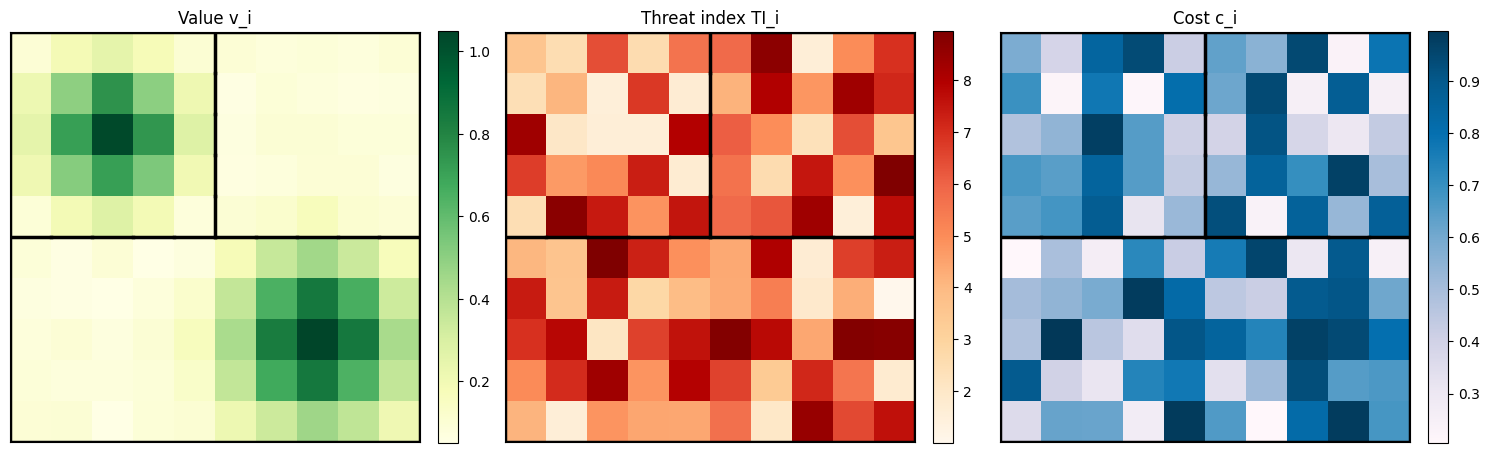

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_heatmap(md, md.value, 'Value v_i', ax=axes[0], cmap='YlGn')
plot_heatmap(md, md.threat, 'Threat index TI_i', ax=axes[1], cmap='OrRd')
plot_heatmap(md, md.cost, 'Cost c_i', ax=axes[2], cmap='PuBu')
plt.tight_layout(); plt.show()


## Load trained theta (or retrain)

By default we load `theta_final.npy` and `train_log.json` from the latest
cluster run. Set `RETRAIN = True` to instead do a fresh (small) training run
inside the notebook.

Loaded theta from ../outputs/slurm/biodiv-2312346/theta_final.npy  (||theta||=0.607)


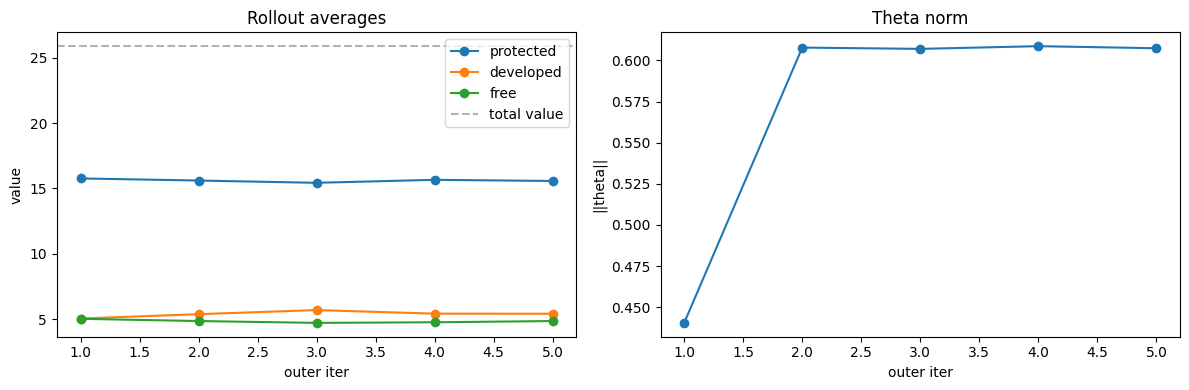

In [3]:
RETRAIN = False

if RETRAIN or LATEST_RUN_DIR is None:
    print('Retraining from scratch (small config).')
    nb_cfg = Config(
        n_controller_candidates=200, n_nature_candidates=200,
        samples_per_iter=200, inner_M=3, outer_iters=3,
        rollout_episodes=5, horizon_T=10,
        lambda_uncertainty=cfg.lambda_uncertainty,
        out_dir='outputs/notebook',
    )
    out = train(nb_cfg, md)
    theta = out['theta']
    log = out['log']
    cfg = nb_cfg
else:
    theta_path = os.path.join(LATEST_RUN_DIR, 'theta_final.npy')
    log_path = os.path.join(LATEST_RUN_DIR, 'train_log.json')
    theta = np.load(theta_path)
    log = json.load(open(log_path))
    print(f'Loaded theta from {theta_path}  (||theta||={np.linalg.norm(theta):.3f})')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(log['outer_iter'], log['avg_protected_value'], label='protected', marker='o')
ax[0].plot(log['outer_iter'], log['avg_developed_value'], label='developed', marker='o')
ax[0].plot(log['outer_iter'], log['avg_free_value'], label='free', marker='o')
ax[0].axhline(md.total_value, color='k', ls='--', alpha=0.3, label='total value')
ax[0].set_xlabel('outer iter'); ax[0].set_ylabel('value'); ax[0].legend(); ax[0].set_title('Rollout averages')
ax[1].plot(log['outer_iter'], log['theta_norm'], marker='o')
ax[1].set_xlabel('outer iter'); ax[1].set_ylabel('||theta||'); ax[1].set_title('Theta norm')
plt.tight_layout(); plt.show()


## Interactive episode

Walks through one episode pausing for input between phases.
Set `INTERACTIVE = True` to pause for Enter at each step (only works in a live
JupyterLab/VS Code session; headless `nbconvert` keeps it `False`).

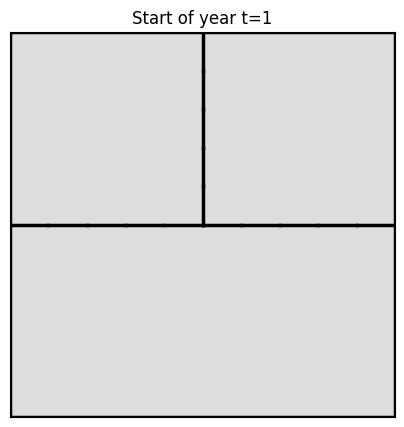

t=1 protected_value=0.00 lost_value=0.00 free_value=25.87 budget=2.00


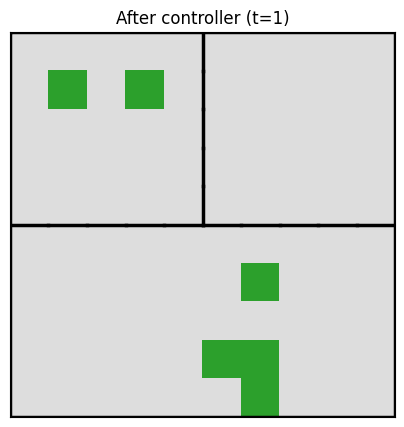

controller chose action with sum=6 cost=1.91


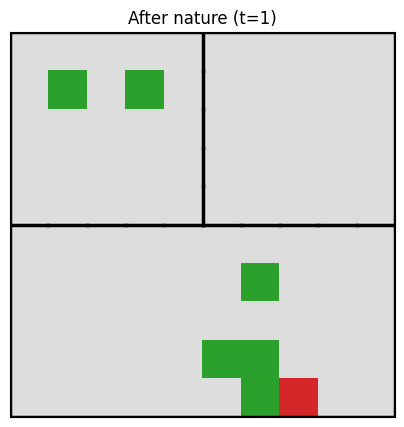

nature chose action with sum=1, slack=0.295
newly protected value: 3.03; newly developed value (capped by overlap): 0.46


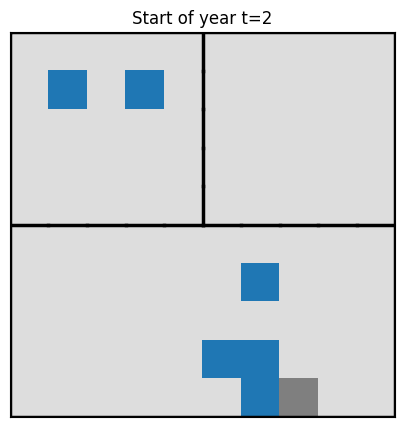

t=2 protected_value=3.03 lost_value=0.46 free_value=22.38 budget=2.00


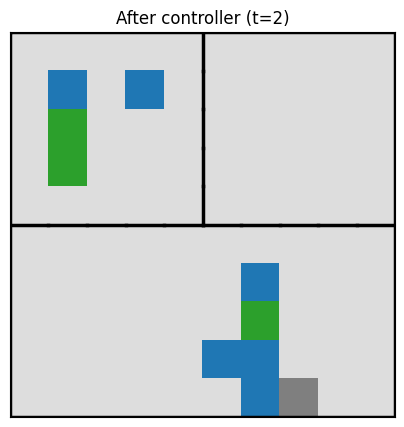

controller chose action with sum=3 cost=1.92


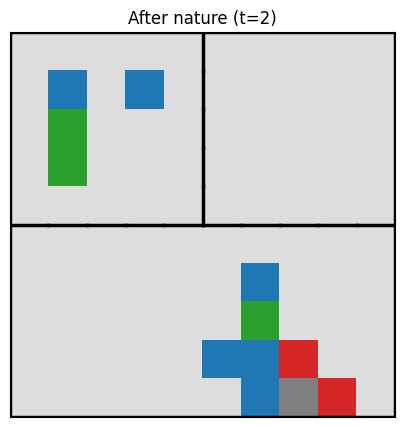

nature chose action with sum=2, slack=2.120
newly protected value: 2.06; newly developed value (capped by overlap): 1.22


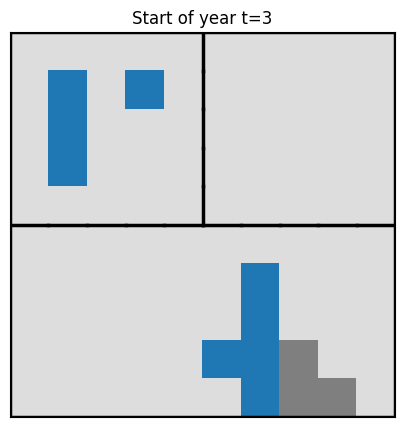

t=3 protected_value=5.09 lost_value=1.68 free_value=19.09 budget=2.00


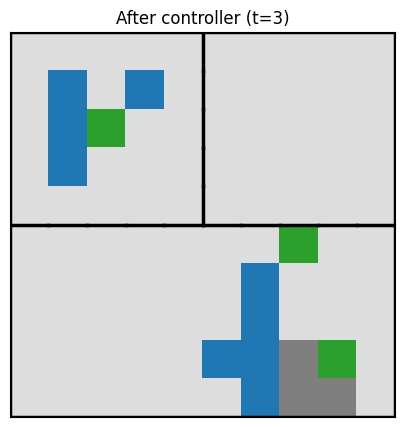

controller chose action with sum=3 cost=1.92


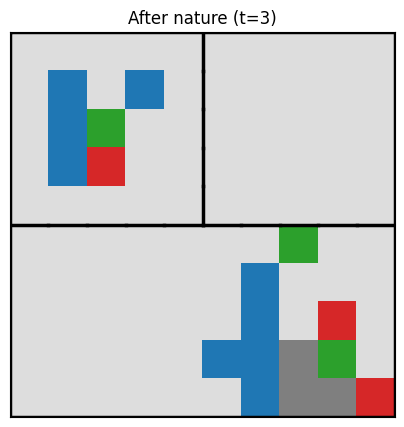

nature chose action with sum=3, slack=0.710
newly protected value: 2.13; newly developed value (capped by overlap): 1.77


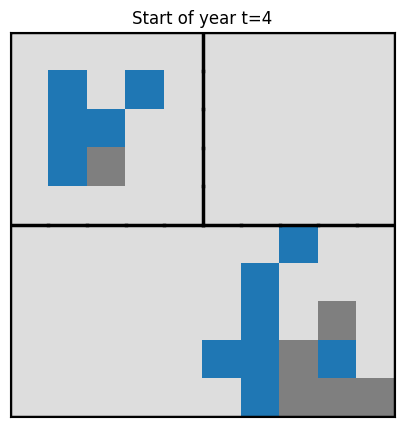

t=4 protected_value=7.23 lost_value=3.45 free_value=15.19 budget=2.00


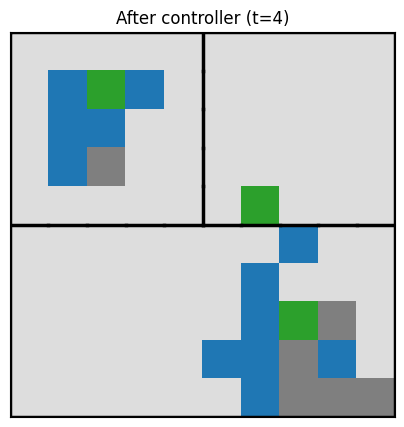

controller chose action with sum=3 cost=1.98


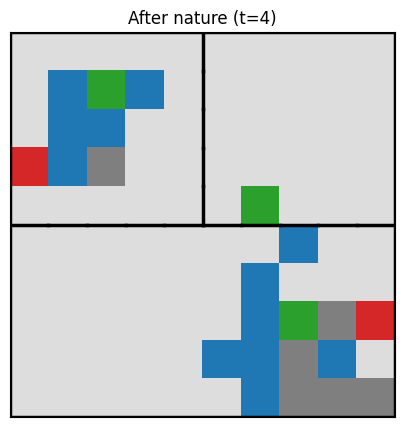

nature chose action with sum=2, slack=1.405
newly protected value: 1.92; newly developed value (capped by overlap): 0.64


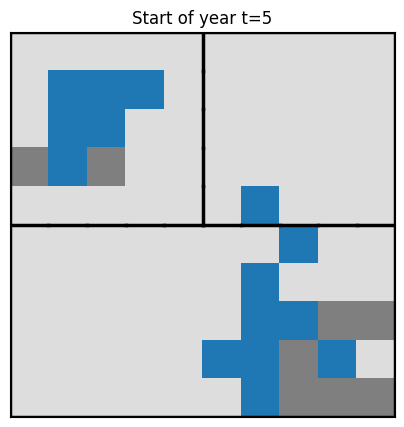

t=5 protected_value=9.14 lost_value=4.10 free_value=12.63 budget=2.00


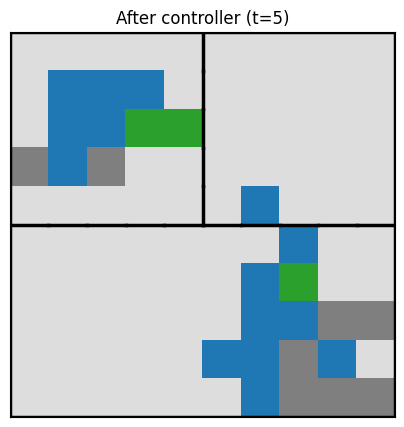

controller chose action with sum=3 cost=1.95


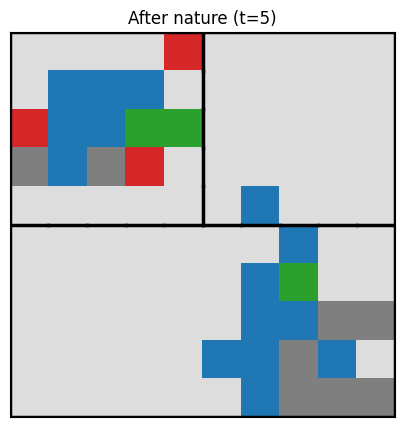

nature chose action with sum=3, slack=2.057
newly protected value: 1.87; newly developed value (capped by overlap): 0.89


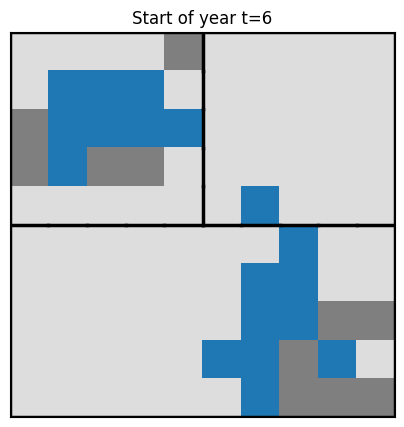

t=6 protected_value=11.01 lost_value=4.99 free_value=9.87 budget=2.00


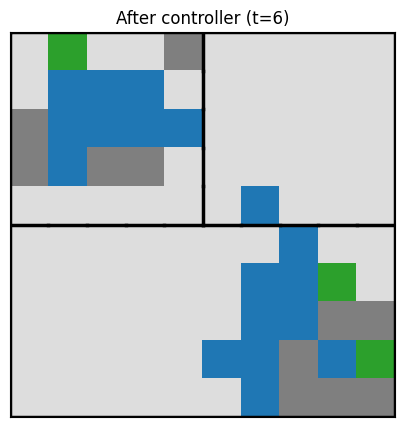

controller chose action with sum=3 cost=1.95


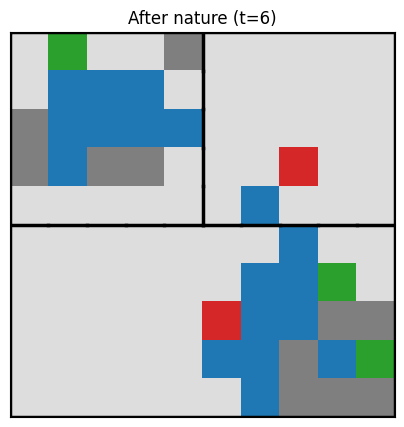

nature chose action with sum=2, slack=0.390
newly protected value: 1.21; newly developed value (capped by overlap): 0.53


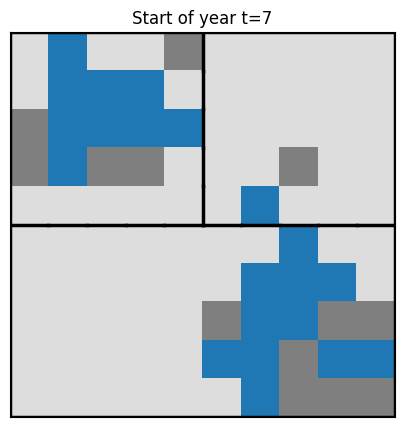

t=7 protected_value=12.23 lost_value=5.51 free_value=8.13 budget=2.00


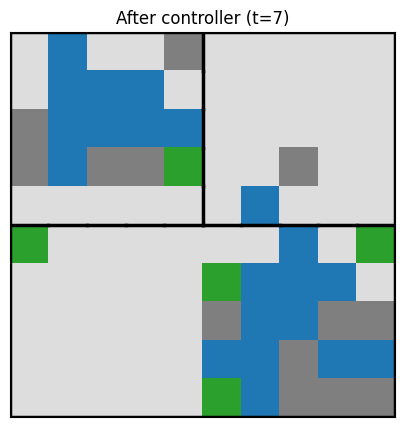

controller chose action with sum=5 cost=1.99


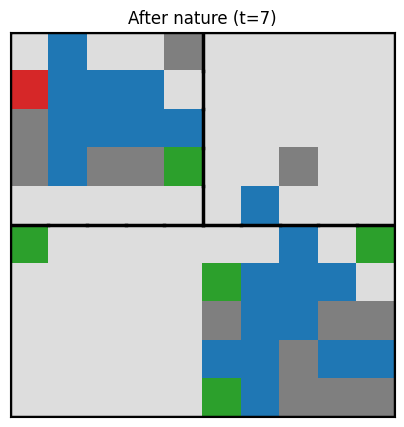

nature chose action with sum=1, slack=0.861
newly protected value: 1.04; newly developed value (capped by overlap): 0.22


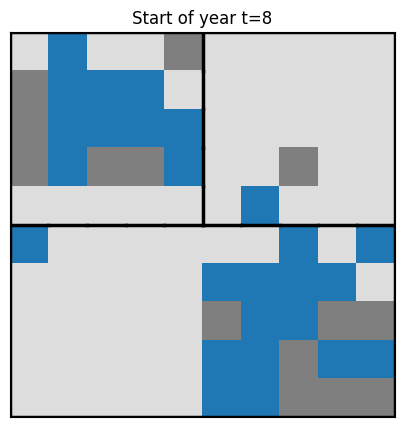

t=8 protected_value=13.27 lost_value=5.73 free_value=6.87 budget=2.00


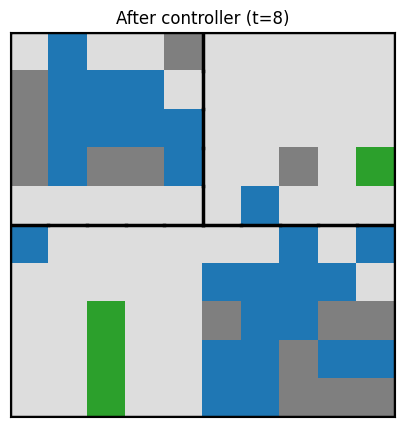

controller chose action with sum=4 cost=1.88


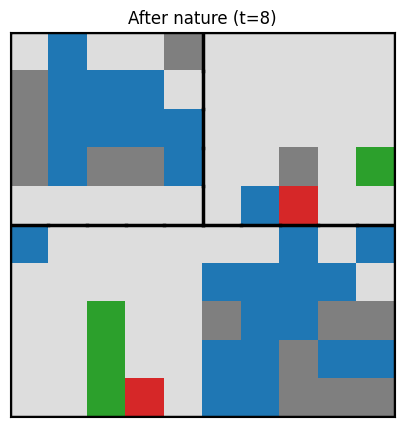

nature chose action with sum=2, slack=0.932
newly protected value: 0.27; newly developed value (capped by overlap): 0.26


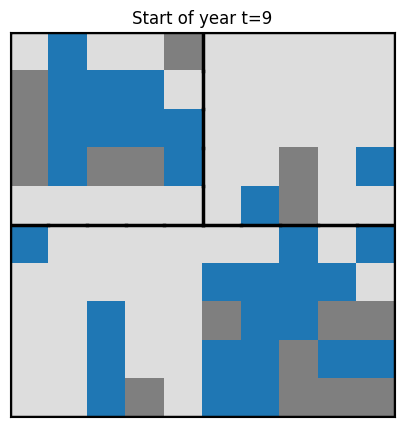

t=9 protected_value=13.54 lost_value=5.99 free_value=6.34 budget=2.00


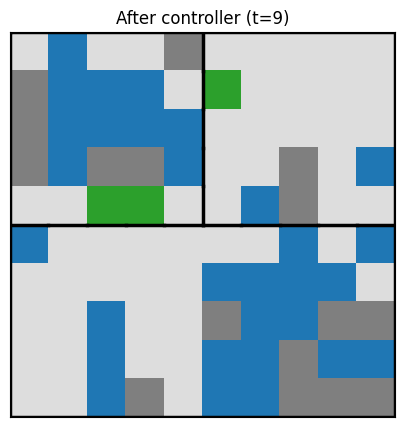

controller chose action with sum=3 cost=1.81


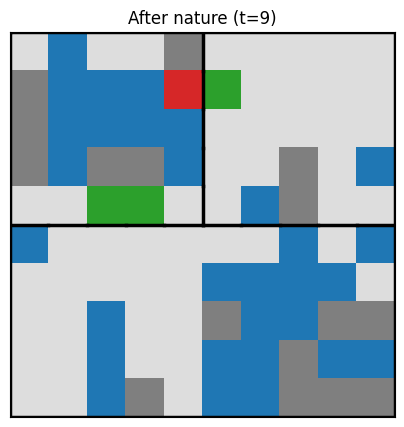

nature chose action with sum=1, slack=1.122
newly protected value: 0.53; newly developed value (capped by overlap): 0.21


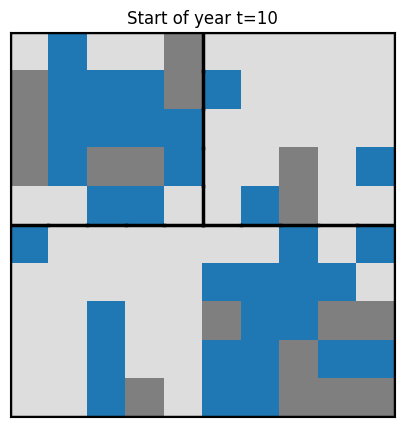

t=10 protected_value=14.07 lost_value=6.20 free_value=5.60 budget=2.00


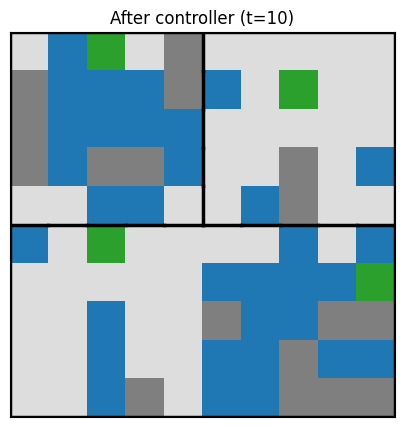

controller chose action with sum=4 cost=1.97


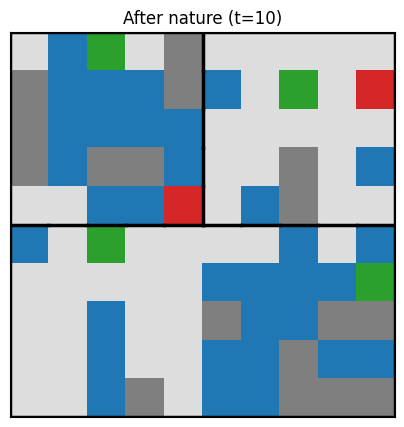

nature chose action with sum=2, slack=0.105
newly protected value: 0.76; newly developed value (capped by overlap): 0.15
Episode complete.


In [4]:
INTERACTIVE = False  # set True to pause for Enter between phases (live UI only)

def _wait(msg='press Enter'):
    if not INTERACTIVE:
        return
    try:
        input(msg)
    except Exception:
        pass

state = initial_state(cfg, md)
for step_idx in range(cfg.horizon_T):
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    plot_state(state, md, ax=ax, title=f'Start of year t={state.t}')
    plt.show()
    pv = float((md.value * state.x).sum())
    dv = float((md.value * state.d).sum())
    fv = float((md.value * ((state.x == 0) & (state.d == 0))).sum())
    print(f't={state.t} protected_value={pv:.2f} lost_value={dv:.2f} free_value={fv:.2f} budget={state.budget:.2f}')
    _wait('Enter to compute controller action...')

    A = generate_controller_candidates(state, md, cfg, rng)
    K = generate_nature_candidates(state, np.zeros(md.n, np.int8), md, cfg, rng)
    Q = q_matrix_batch(state, A, K, theta, md, cfg)
    pi, omega, v = solve_matrix_game(Q)
    j = int(np.argmax(pi))
    a = A[j]
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    plot_state(state, md, a=a, ax=ax, title=f'After controller (t={state.t})')
    plt.show()
    print(f'controller chose action with sum={int(a.sum())} cost={float((md.cost*a).sum()):.2f}')
    _wait('Enter to compute nature action...')

    K2 = generate_nature_candidates(state, a, md, cfg, rng)
    Q2 = q_matrix_batch(state, A[j:j+1], K2, theta, md, cfg)
    l = int(np.argmin(Q2[0]))
    k = K2[l]
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    plot_state(state, md, a=a, k=k, ax=ax, title=f'After nature (t={state.t})')
    plt.show()
    from src.dynamics import likelihood_slack
    print(f'nature chose action with sum={int(k.sum())}, slack={likelihood_slack(state, state.d | (k & (1-(state.x | a))), md, cfg):.3f}')
    print(f'newly protected value: {float((md.value * a).sum()):.2f}; newly developed value (capped by overlap): {float((md.value * (k & (1-(state.x | a)))).sum()):.2f}')
    _wait('Enter for next year...')

    state = step(state, a, k, cfg)

print('Episode complete.')
